# <span style="color:rgb(213,80,0)">Lithium plating example</span>

In This example, we illustrate the implementation of Lithium plating.

The modeling equations are taken from

Hein, Danner and Latz "An Electrochemical Model of Lithium Plating and Stripping in Lithium Ion Batteries" In: ACS Applied Energy Materials (2022) [http://dx.doi.org/10.1021/acsaem.0c01155](http://dx.doi.org/10.1021/acsaem.0c01155)

## Parameter setup

We load a set of NMC\-graphite material parameters


In [1]:
filename = fullfile('ParameterData'        , ...
                    'BatteryCellParameters', ...
                    'LithiumIonBatteryCell', ...
                    'lithium_ion_battery_nmc_graphite.json');


jsonstruct = parseBattmoJson(filename);


We define some shortcuts


In [2]:
ne      = 'NegativeElectrode';
pe      = 'PositiveElectrode';
lp      = 'LithiumPlating';
co      = 'Coating';
am      = 'ActiveMaterial';
itf     = 'Interface';
sd      = 'SolidDiffusion';


We do not include the thermal effects


In [3]:
jsonstruct.use_thermal = false;


We include the lithium plating effect


In [4]:
jsonstruct.(ne).(co).(am).useLithiumPlating = true;


OCP is computed via a function described in the article (S\-5), which has been written as a matlab function `computeOCP_Graphite_Latz`. Let us plot this function



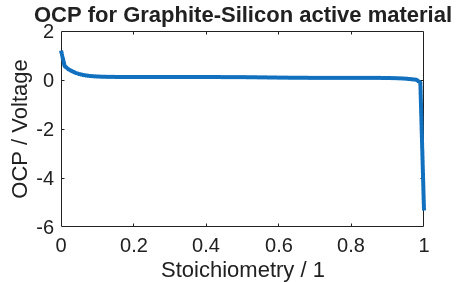

In [5]:
set(0, 'defaultlinelinewidth', 3);
set(0, 'defaultaxesfontsize', 15);


theta = linspace(0, 1, 100);
OCP = computeOCP_Graphite_Latz(theta);


plot(theta, OCP);
xlabel('Stoichiometry / 1')
ylabel('OCP / Voltage')
title('OCP for Graphite-Silicon active material')


We use this OCP function in our material. Note the use of the function interface. The function should be in the matlab path (this is the case here by installation default).


In [6]:
func.functionFormat = 'named function';
func.functionName   = 'computeOCP_Graphite_Latz';
func.argumentList   = {'stoichiometry'};


jsonstruct.(ne).(co).(am).(itf).openCircuitPotential = func;


We do not include the entropy change


In [7]:
jsonstruct.(ne).(co).(am).(itf).includeEntropyChange = false;


We load the lithium plating specific data


In [8]:
jsonstruct_lithium_plating = parseBattmoJson(fullfile('Examples', 'Advanced', 'Plating', 'lithium_plating.json'));
viewStruct(jsonstruct_lithium_plating);

{
  "LithiumPlating": {
    "symmetryFactorPlating": 0.3,
    "symmetryFactorStripping": 0.7,
    "symmetryFactorChemicalIntercalation": 0.5,
    "reactionRatePlating": 4.635E-6,
    "reactionRateChemicalIntercalation": 2.89E-9,
    "reactionRateDirectIntercalation": 6.656E-9,
    "thresholdParameter": 1.173E-23,
    "limitAmount": 1.173E-17,
    "platedLiMonolayerThickness": 2.78E-10
  }
}


We add this parameter set to our global parameter structure


In [9]:
jsonstruct.(ne).(co).(am).LithiumPlating = jsonstruct_lithium_plating.LithiumPlating;


filename = fullfile('Examples', 'JsonDataFiles', 'geometry1d.json');
jsonstruct_geometry = parseBattmoJson(filename);


jsonstruct = mergeStructs({jsonstruct, jsonstruct_geometry});


We change control to charge control


In [10]:
jsonstruct.Control.controlPolicy      = 'CCCharge';
jsonstruct.Control.CRate              = 1;
jsonstruct.SOC                        = 0.01;
jsonstruct.Control.upperCutoffVoltage = 4.5;
jsonstruct.Control.useCVswitch        = true;


We run the simulation


In [11]:
output = runBatteryJson(jsonstruct, 'runSimulation', true);


## Plotting

In [12]:
close all


states = output.states;
model  = output.model;


time = cellfun(@(state) state.time, states);
E    = cellfun(@(state) state.Control.E, states);


We plot the voltage curve



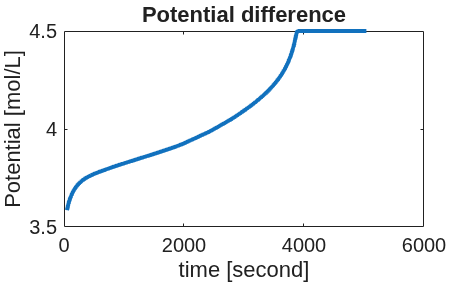

In [13]:
figure
plot(time, E);
xlabel('time [second]');
ylabel('Potential [mol/L]');
title('Potential difference');


We populate the state variables with all the variables known to the model which are used in the simulation and also the plated thickness, which is a post processed variable (not needed directly in the simulation).


In [14]:
for istate = 1 :  numel(states)
    states{istate} = model.addVariables(states{istate});
    states{istate} = model.evalVarName(states{istate}, {ne, co, am, lp, 'platedThickness'});
end


We automate the extraction of the variables of interest from the states that we want to plot


In [15]:
varnames = {{ne, co, am, sd, 'cSurface'}           , ...
            {ne, co, am, lp, 'platedConcentration'}, ...
            {ne, co, am, lp, 'etaPlating'}         , ...
            {ne, co, am, lp, 'etaChemical'}        , ...
            {ne, co, am, lp, 'surfaceCoverage'}    , ...
            {ne, co, am, lp, 'platedThickness'}};


We register here the description of the variable and the unit. This structure will be used in the ploting.


In [16]:
descriptions = {{'Surface Concentration', 'mol/m^3'}, ...
                {'Plated Lithium Concentration', 'mol/m^3'}, ...
                {'Plating Overpotential', 'V'}, ...
                {'Chemical Overpotential', 'V'}, ...
                {'Surface Coverage', '1'}, ...
                {'Plated Thickness', 'm'}}; % all SI units


We fetch the variables using the getProp method, which is convenient here when given the variable identifier as a cell array.


In [17]:
vals = {};


for ivar = 1 : numel(varnames)


    v = cellfun(@(state) model.getProp(state, varnames{ivar}), states, 'un', false);
    vals{ivar} = [v{:}];
end


We recover the position in the coating electrode


In [18]:
x = output.model.(ne).(co).grid.cells.centroids;
legtxt = arrayfun(@(x) sprintf('x = %g', x), x, 'un', false);


We plot the variable of interest



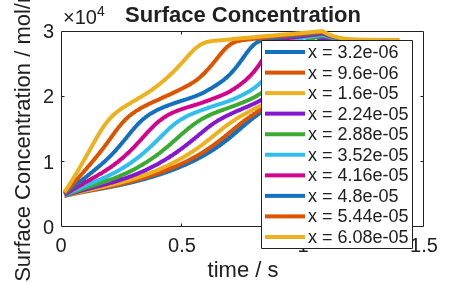


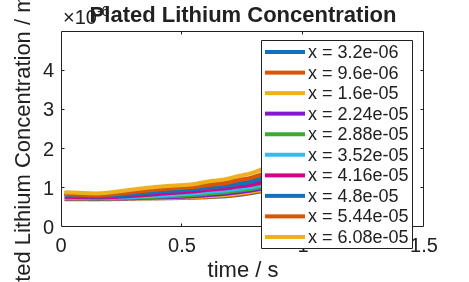

In [19]:
for ivar = 1 : numel(varnames)
    figure
    plot(time/hour, vals{ivar});
    title(descriptions{ivar}{1});
    ylabel(sprintf('%s / %s', descriptions{ivar}{1}, descriptions{ivar}{2}));
    xlabel('time / s');
    legend(legtxt)
end


<center>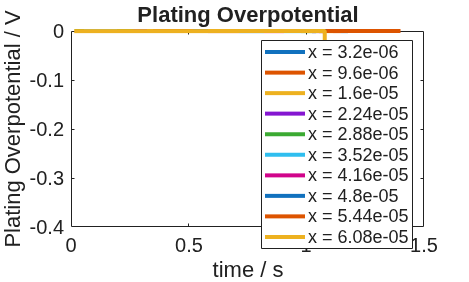</center>

<center>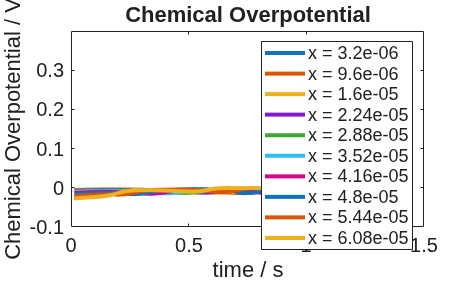</center>

<center>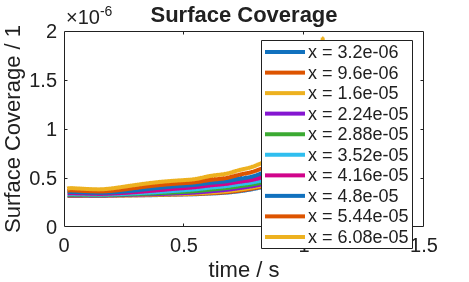</center>

<center>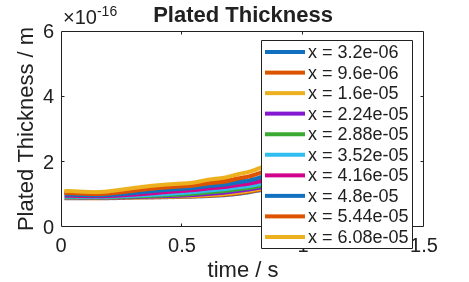</center>